In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from pathlib import Path

# Sobe de codigos/ para a raiz do projeto
BASE = Path.cwd().parent         
DADOS = BASE / "dados" / "brutos"
FIGURAS = BASE / "resultados" / "figuras"


#Objetivo aqui é transformar os dados de hiato de produto em um dataframe para melhor trabalhar com os dados

data_gap = pd.read_excel(DADOS/"gap.xlsx", header=2)
print('Informações da base de dados:')
print(data_gap.info())
# Selecionamos apenas as colunas de interesse
df_gap = data_gap[["Quarterly", "Output gap"]]
#Eliminamos as linhas que não possuiam dados
df_gap = df_gap.drop([0,1])

#Como nossa análise será pautada por ano, pegaremos apenas os resultados dos últimos trimestres
gap_ano = df_gap[df_gap['Quarterly'].str.contains('4Q$', na = False)]

#Agora garantimos que ambas as colunas tem o tipo do dado float e int
gap_ano['Quarterly'] = gap_ano['Quarterly'].str.replace(".4Q", '',regex=False).astype(int)
gap_ano['Output gap'] = gap_ano['Output gap'].astype(float)
gap_ano = gap_ano.rename(columns={'Quarterly':'Year'})



Informações da base de dados:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 176 entries, 0 to 175
Data columns (total 13 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Quarterly                          174 non-null    object 
 1   Output gap                         174 non-null    object 
 2   Capital input gap                  174 non-null    object 
 3   Labor input gap                    174 non-null    object 
 4   Tankan factor utilization index    93 non-null     object 
 5   Tankan factor utilization index.1  55 non-null     object 
 6   Unnamed: 6                         0 non-null      float64
 7   Beveridge ratio                    167 non-null    object 
 8   Tankan employment conditions DI    92 non-null     object 
 9   Tankan employment conditions DI.1  78 non-null     object 
 10  Unemployment rate                  167 non-null    object 
 11  Employment rate gap         

C:\Users\tgu12\AppData\Local\Temp\ipykernel_13264\1604042846.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gap_ano['Quarterly'] = gap_ano['Quarterly'].str.replace(".4Q", '',regex=False).astype(int)
C:\Users\tgu12\AppData\Local\Temp\ipykernel_13264\1604042846.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gap_ano['Output gap'] = gap_ano['Output gap'].astype(float)


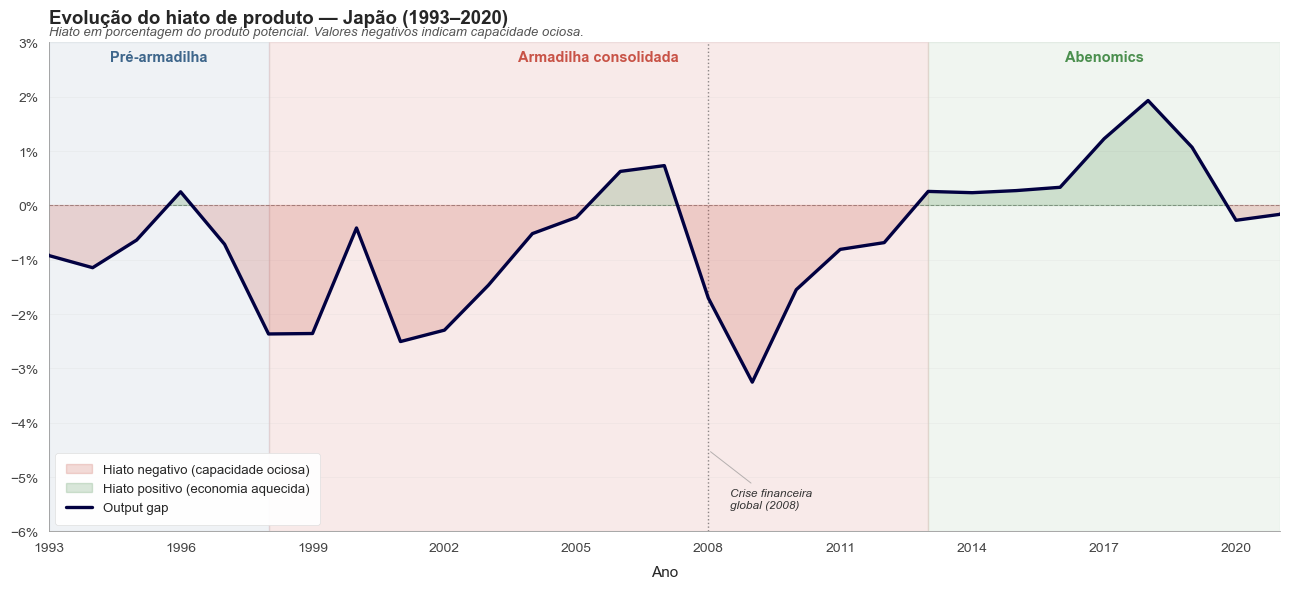

In [4]:
#Gráfico:
#Definindo o fundo e padrões de fontes
sns.set_style('white')
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 10,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'legend.fontsize': 9,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
})


#Definindo váriaveis auxiliares
anos    = gap_ano['Year']
valores = gap_ano['Output gap']

#Paleta de cores
COR_GAP      = '#c0392b'
COR_NEGATIVO = '#c0392b'
COR_POSITIVO = '#2e7d32'
COR_LINHA    = "#020141"

#Criando o gráfico
fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor('white')

#Divisão de cor entre os períodos Pré-Armadilha,Armadilha consolidada e Abenomics
ax.axvspan(1993, 1998, alpha=0.07, color='#1f4e79', zorder=0)
ax.axvspan(1998, 2013, alpha=0.10, color=COR_GAP,   zorder=0)
ax.axvspan(2013, 2021, alpha=0.07, color='#2e7d32', zorder=0)

#Limites dos eixos
ax.set_ylim(-6, 3)
ax.set_xlim(1993, 2021)

#Títulos dos períodos 
y_label = 2.65
ax.text(1995.5, y_label, 'Pré-armadilha',
        ha='center', fontsize=10.5, color='#1f4e79', weight='bold', alpha=0.85)
ax.text(2005.5, y_label, 'Armadilha consolidada',
        ha='center', fontsize=10.5, color=COR_GAP, weight='bold', alpha=0.85)
ax.text(2017, y_label, 'Abenomics',
        ha='center', fontsize=10.5, color='#2e7d32', weight='bold', alpha=0.85)

#Linha de referência
ax.axhline(0, color='#333', linewidth=0.7, linestyle='--', alpha=0.45, zorder=1)

#Marcação da crise de 2008
ax.axvline(2008, color='#333', linewidth=1.0, linestyle=':', alpha=0.55, zorder=1)
ax.annotate('Crise financeira\nglobal (2008)',
            xy=(2008, -4.5), xytext=(2008.5, -5.4),
            fontsize=8.5, ha='left', va='center',
            color='#333', style='italic',
            arrowprops=dict(arrowstyle='-', color='#888', alpha=0.6, lw=0.7))

# Preenchendo os espaços entre a linha 0 e o hiato de produto
ax.fill_between(anos, valores, 0,
                where=(valores < 0),
                color=COR_NEGATIVO, alpha=0.18, interpolate=True, zorder=2,
                label='Hiato negativo (capacidade ociosa)')
ax.fill_between(anos, valores, 0,
                where=(valores >= 0),
                color=COR_POSITIVO, alpha=0.18, interpolate=True, zorder=2,
                label='Hiato positivo (economia aquecida)')

#Linha principal do Hiato
sns.lineplot(data=gap_ano, x='Year', y='Output gap',
             linewidth=2.4, color=COR_LINHA, ax=ax, zorder=3,
             label='Output gap')

#Formatação dos eixos marcando de 3 em 3 anos e colocando em porcentagem o eixo Y
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
ax.set_xticks(range(1993, 2022, 3))

ax.set_xlabel('Ano', fontsize=11, labelpad=8)
ax.set_ylabel('', fontsize=11)
ax.set_title('Evolução do hiato de produto — Japão (1993–2020)',
             fontsize=13.5, weight='bold', pad=14, loc='left')

#Subtítulo
ax.text(0.0, 1.015,
        'Hiato em porcentagem do produto potencial. Valores negativos indicam capacidade ociosa.',
        transform=ax.transAxes, fontsize=9.5, style='italic',
        color='#555', ha='left')

#Legenda
legend = ax.legend(loc='lower left', framealpha=0.95, fontsize=9.5,
                   frameon=True, edgecolor='#ddd', borderpad=0.8)
legend.get_frame().set_linewidth(0.5)

ax.grid(axis='y', alpha=0.22, linewidth=0.5)
ax.grid(axis='x', visible=False)

#Ajustando as bordas
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#999')
ax.spines['bottom'].set_color('#999')
ax.spines['left'].set_linewidth(0.6)
ax.spines['bottom'].set_linewidth(0.6)

ax.tick_params(colors='#444', length=4, width=0.6)

#Exportando o gráfico
plt.tight_layout()
plt.savefig(FIGURAS/'grafico_output_gap.png', dpi=200,
            bbox_inches='tight', facecolor='white')
plt.show()



_Dividir a análise em duas:_


_TAXA DE JUROS NATURAL_

In [5]:
#Gráfico Baseado nas estimativas do modelo de Goy and Iwasaki (2024)

tx_juros = pd.read_excel(DADOS/"natural_interest_rate_japan.xlsx",header = 2)
print('Informações da base de dados:')
print(tx_juros.info())

tx_juros = tx_juros[["Unnamed: 2", "Goy and Iwasaki (2024)"]]

#Como nossa análise será pautada por ano, pegaremos apenas os resultados dos últimos trimestres
tx_n_y = tx_juros[tx_juros['Unnamed: 2'].str.contains('Q4$', na = False)]
tx_n_y['Unnamed: 2'] = tx_n_y['Unnamed: 2'].str.replace("Q4", '',regex=False).astype(int)


# Renomeia as colunas 
tx_n_y = tx_n_y.rename(columns={
    'Unnamed: 2': 'Year',
    'Goy and Iwasaki (2024)': 'Natural interest rate'
})
#Garantindo que Year será int e os valores serão float
tx_n_y['Year'] = tx_n_y['Year'].astype(int)
tx_n_y['Natural interest rate'] = tx_n_y['Natural interest rate'].astype(float)


tx_n_y.tail()


Informações da base de dados:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 135 entries, 0 to 134
Data columns (total 9 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Unnamed: 0                             0 non-null      float64
 1   Unnamed: 1                             34 non-null     float64
 2   Unnamed: 2                             135 non-null    object 
 3   Del Negro et al. (2017)                135 non-null    float64
 4   Goy and Iwasaki (2024)                 131 non-null    float64
 5   Holston, Laubach, and Williams (2023)  135 non-null    float64
 6   Imakubo, Kojima, and Nakajima (2015)   123 non-null    float64
 7   Nakajima et al. (2023)                 123 non-null    float64
 8   Okazaki and Sudo (2018)                135 non-null    float64
dtypes: float64(8), object(1)
memory usage: 9.6+ KB
None


C:\Users\tgu12\AppData\Local\Temp\ipykernel_13264\696984313.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tx_n_y['Unnamed: 2'] = tx_n_y['Unnamed: 2'].str.replace("Q4", '',regex=False).astype(int)


,Year,Natural interest rate
115,2020,-0.701056
119,2021,-0.753173
123,2022,-0.841298
127,2023,-1.005236
131,2024,-0.972300


_Plotando gráfico_

EVOLUÇÃO TAXA DE JUROS NATURAL DE 1993 - 2000


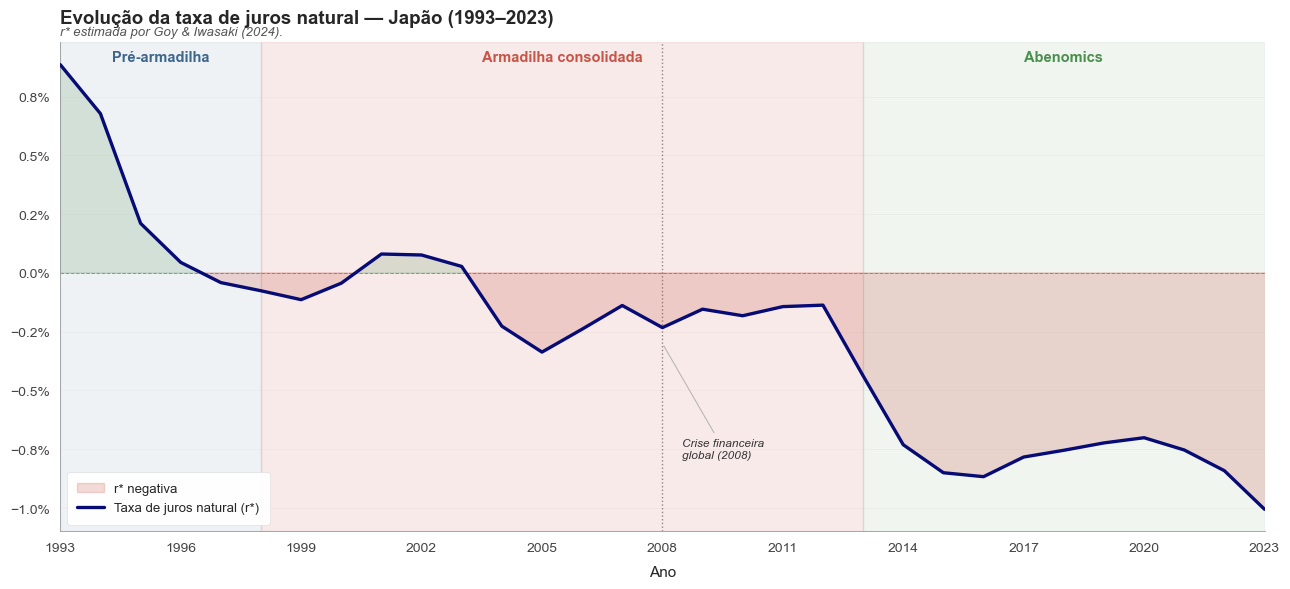

In [6]:
#Gráfico taxa de juros natural 1993 - 2023

#Configuração de estilo global
sns.set_style('white')
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 10,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'legend.fontsize': 9,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
})



#Cores escolhidas
COR_NATURAL  = "#070B76"
COR_POSITIVO = '#2e7d32'
COR_NEGATIVO = '#c0392b'

fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor('white')

# Cores dos períodos 
ax.axvspan(1993, 1998, alpha=0.07, color='#1f4e79', zorder=0)
ax.axvspan(1998, 2013, alpha=0.10, color='#c0392b', zorder=0)
ax.axvspan(2013, 2023, alpha=0.07, color='#2e7d32', zorder=0)

ax.set_xlim(1993, 2023)



# Título dos períodos
y_label = 0.9  
ax.text(1995.5, y_label, 'Pré-armadilha',
        ha='center', fontsize=10.5, color='#1f4e79', weight='bold', alpha=0.85)
ax.text(2005.5, y_label, 'Armadilha consolidada',
        ha='center', fontsize=10.5, color='#c0392b', weight='bold', alpha=0.85)
ax.text(2018, y_label, 'Abenomics',
        ha='center', fontsize=10.5, color='#2e7d32', weight='bold', alpha=0.85)

ax.axhline(0, color='#333', linewidth=0.7, linestyle='--', alpha=0.45, zorder=1)

# Marcação Crise financeira global (2008)
ax.axvline(2008, color='#333', linewidth=1.0, linestyle=':', alpha=0.55, zorder=1)
ax.annotate('Crise financeira\nglobal (2008)',
            xy=(2008, -0.3), xytext=(2008.5, -0.75),
            fontsize=8.5, ha='left', va='center',
            color='#333', style='italic',
            arrowprops=dict(arrowstyle='-', color='#888', alpha=0.6, lw=0.7))

# Preenchimento dos hiatos
ax.fill_between(tx_n_y['Year'], tx_n_y['Natural interest rate'], 0,
                where=(tx_n_y['Natural interest rate'] >= 0),
                color=COR_POSITIVO, alpha=0.15, interpolate=True, zorder=2)
ax.fill_between(tx_n_y['Year'], tx_n_y['Natural interest rate'], 0,
                where=(tx_n_y['Natural interest rate'] < 0),
                color=COR_NEGATIVO, alpha=0.18, interpolate=True, zorder=2,
                label='r* negativa')

# Linha principal
sns.lineplot(data=tx_n_y, x='Year', y='Natural interest rate',
             linewidth=2.4, color=COR_NATURAL, ax=ax, zorder=3,
             label='Taxa de juros natural (r*)')

ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=1))

ax.set_xticks(range(1993, 2024, 3))

ax.set_xlabel('Ano', fontsize=11, labelpad=8)
ax.set_ylabel('', fontsize=11)
ax.set_title('Evolução da taxa de juros natural — Japão (1993–2023)',
             fontsize=13.5, weight='bold', pad=14, loc='left')

ax.text(0.0, 1.015,
        'r* estimada por Goy & Iwasaki (2024).',
        transform=ax.transAxes, fontsize=9.5, style='italic',
        color='#555', ha='left')

#Legenda
legend = ax.legend(loc='lower left', framealpha=0.95, fontsize=9.5,
                   frameon=True, edgecolor='#ddd', borderpad=0.8)
legend.get_frame().set_linewidth(0.5)

#Linhas de grade na horizontal
ax.grid(axis='y', alpha=0.22, linewidth=0.5)
ax.grid(axis='x', visible=False)

#Ajuste nas bordas
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#999')
ax.spines['bottom'].set_color('#999')
ax.spines['left'].set_linewidth(0.6)
ax.spines['bottom'].set_linewidth(0.6)

#Marcações dos eixos em cinza
ax.tick_params(colors='#444', length=4, width=0.6)

#Salva a figura
plt.tight_layout()
plt.savefig(FIGURAS/'geral_natural_interest_rate.png', dpi=200,
            bbox_inches='tight', facecolor='white')
plt.show()